# Regresión Conjunta (SUR) con Errores Agrupados
## Las cinco ecuaciones juntas: ¿'clase' mueve algo en el sistema?

Cinco regresiones en logaritmo (una por contaminante) con regresores idénticos,
estimadas como sistema para hacer UNA prueba conjunta de Wald sobre 'clase'.
Se comparan dos especificaciones: la cruda (sin controles) y la preferida
(estación + mes + día de semana). Cada prueba conjunta se calcula con DOS matrices
de covarianza, la convencional (errores independientes) y la agrupada por semana,
para medir cuánto cambia la inferencia al reconocer la dependencia temporal.
Incluye pruebas de falsación (clase falsa), leave-one-station-out y PC1.

**Data access / Acceso a los datos.** The SIMA measurements used here are not
redistributed in this repository (SIMA provided them for this study on the condition
that they are not disseminated); the repository holds the code, the official school
calendar and all derived results. This notebook reads files that notebooks 00 and 01
build from those measurements, and its configuration cell stops with a clear message
if they are missing. To rebuild them, request the annual workbooks from SIMA, place
them in `data_raw/` and run notebook 00 (its header gives the exact file format). /
Las mediciones de SIMA no se redistribuyen en este repositorio (SIMA las entregó para
este estudio con la condición de no difundirlas); el repositorio contiene el código, el
calendario oficial y todos los resultados derivados. Este notebook lee archivos que los
notebooks 00 y 01 construyen a partir de esas mediciones, y su celda de configuración
se detiene con un mensaje claro si faltan. Para reconstruirlos, solicite los libros
anuales a SIMA, colóquelos en `data_raw/` y corra el notebook 00 (su encabezado da el
formato exacto).

**Role in the analysis / Papel en el análisis.** Day-level contrasts (Eq. 3 of the article): the between-day comparison reported alongside the primary analysis, including the conventional-vs-clustered covariance comparison. / Contrastes de nivel de día (ecuación 3 del artículo): la comparación entre días que se reporta junto al análisis principal, incluida la comparación de covarianza convencional contra agrupada. The analytical hierarchy of the whole repository is stated in the README. / La jerarquía analítica de todo el repositorio está en el README.

## 1. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
import json
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

output_dir = Path('../data_processed')
resultados_dir = output_dir / 'resultados_metodos'
graficos_dir = output_dir / 'graficos_metodos'

print("Librerías importadas exitosamente")

# Verificación de los datos de entrada (no se redistribuyen; ver la nota del encabezado)
# / Input data check (not redistributed; see the note in the header)
archivos_requeridos = [output_dir / 'panel_pico_hibrido.csv',
                       output_dir / 'panel_pico_MIMA.csv']
faltantes = [str(a) for a in archivos_requeridos if not a.exists()]
if faltantes:
    raise FileNotFoundError(
        "Faltan archivos derivados de las mediciones de SIMA, que no se redistribuyen en este repositorio. "
        "Solicite los libros anuales a SIMA, colóquelos en data_raw/ y corra los notebooks 00 y 01. / "
        "Files derived from the SIMA measurements are missing; they are not redistributed in this repository. "
        "Request the annual workbooks from SIMA, place them in data_raw/ and run notebooks 00 and 01. "
        f"Faltantes / missing: {faltantes}")
print(f"Datos de entrada encontrados / input data found: {len(archivos_requeridos)} archivos")

Librerías importadas exitosamente
Datos de entrada encontrados / input data found: 2 archivos


## 2. Funciones del estimador (idénticas al notebook 05)

### Las matemáticas (las mismas del notebook 05, ahora sobre NIVELES)

Aquí la variable dependiente no es el gap sino el log del nivel de la franja pico,
una ecuación por contaminante $j$:

$$ \log y^{(j)}_{st} = \alpha^{(j)} + \beta^{(j)}\,\text{clase}_t + \text{controles} + \varepsilon^{(j)}_{st}, \qquad j = 1,\dots,5 $$

Como las 5 ecuaciones comparten la misma matriz $X$, el SUR coincide con OLS ecuación
por ecuación; la covarianza conjunta agrupada por semana y la prueba de Wald
$W = b'V_b^{-1}b \sim \chi^2_5$ son exactamente las del notebook 05. La diferencia
entre los dos notebooks no es el estimador, es la PREGUNTA: aquí "¿el periodo
lectivo sube el NIVEL de la mañana pico?" (identificación por controles de
calendario); allá "¿se abre la brecha DENTRO del mismo día?" (identificación por
construcción).

### Dos covarianzas para la misma prueba: cuánto cuesta ignorar la dependencia

La misma hipótesis conjunta se prueba con dos matrices de covarianza de $b$:

- **Convencional**: $\hat V^{\,conv} = \hat\Sigma \otimes (X'X)^{-1}$ con
  $\hat\Sigma = \hat U'\hat U/(n-k)$. Supone errores independientes entre
  observaciones: el error del lunes no tiene relación con el del martes, y las seis
  zonas del mismo día tampoco se relacionan entre sí.
- **Agrupada por semana ISO**: la $\hat V$ de arriba, que permite cualquier
  correlación entre los errores de una misma semana (días consecutivos y zonas del
  mismo día incluidos).

Como la hipótesis restringe UN solo coeficiente por ecuación (rango 1), el Wald con
covarianza convencional es la $T^2$ de Hotelling, y en ese caso los cuatro
estadísticos clásicos de MANOVA (Pillai, Wilks, Hotelling-Lawley y Roy) coinciden en
la misma F. Por eso la comparación convencional-vs-agrupada aísla exactamente el
papel de la covarianza: mismo modelo, mismo estadístico, solo cambia lo que se
supone sobre la dependencia de los errores. Abajo se verifica numéricamente contra
la traza de Pillai de statsmodels.

### Supuestos de este diseño

Aquí la identificación depende de los CONTROLES (no de la construcción, como en el
notebook 05): el supuesto clave es que, fijando estación, mes y día de la semana, la
asignación de 'clase' no está correlacionada con nada más que mueva la contaminación.
Es un supuesto más fuerte que el del gap, y por eso este diseño es el marco conjunto y
el de franjas es el principal. Se somete a prueba con las pruebas de falsación
(clase falsa) y el leave-one-station-out de la sección 6, y la dependencia temporal
de los errores se maneja agrupando por semana (diagnóstico DW en el notebook 05,
robustez en el 08).

### Hipótesis que se prueban

- Por contaminante: $H_0\!: \beta_j = 0$ (el periodo lectivo no mueve el NIVEL
  de la mañana pico del contaminante $j$) contra $H_1\!: \beta_j \neq 0$.
- Conjunta (Wald): $H_0\!: \beta_{\text{CO}} = \beta_{\text{NO}_2} = \beta_{\text{O}_3} = \beta_{\text{PM}_{10}} = \beta_{\text{PM}_{2.5}} = 0$,
  probada con las dos covarianzas.
- PC1: $H_0$ de que el índice común de carga contaminante no cambia entre regímenes.

In [2]:
def matriz_diseno(df, especificacion='preferida'):
    """
    Construye la matriz de diseño: constante + clase + efectos fijos.
    'cruda' = solo clase; 'preferida' = estación + mes + día de semana.
    """
    piezas = []
    if especificacion != 'cruda':
        piezas.append(pd.get_dummies(df['estacion'], prefix='est', drop_first=True).astype(float))
    if especificacion == 'preferida':
        piezas.append(pd.get_dummies(df['mes'], prefix='mes', drop_first=True).astype(float))
        piezas.append(pd.get_dummies(df['dow'], prefix='dow', drop_first=True).astype(float))
    X = pd.concat([pd.Series(1.0, index=df.index, name='const'),
                   df['clase'].astype(float)] + piezas, axis=1)
    return X

def sur_wald_cluster(df, X, columnas_y, cluster):
    """
    OLS por ecuación (regresores idénticos) + covarianza conjunta agrupada -> Wald conjunto.
    """
    Xv = X.values
    n, k = Xv.shape
    XtX_inv = np.linalg.inv(Xv.T @ Xv)
    Y = df[columnas_y].values
    B = XtX_inv @ Xv.T @ Y
    U = Y - Xv @ B
    J = len(columnas_y)
    grupos = df[cluster].values
    orden = np.argsort(grupos, kind='stable')
    Xg, Ug, gg = Xv[orden], U[orden], grupos[orden]
    S = np.zeros((J * k, J * k))
    inicios = np.flatnonzero(np.r_[True, gg[1:] != gg[:-1]])
    fines = np.r_[inicios[1:], len(gg)]
    G = len(inicios)
    for s, e in zip(inicios, fines):
        sg = (Xg[s:e].T @ Ug[s:e]).T.reshape(-1)
        S += np.outer(sg, sg)
    A = np.kron(np.eye(J), XtX_inv)
    V = A @ S @ A
    V *= (G / (G - 1)) * ((n - 1) / (n - k))
    idx_clase = X.columns.get_loc('clase')
    seleccion = [j * k + idx_clase for j in range(J)]
    b = B[idx_clase, :]
    Vb = V[np.ix_(seleccion, seleccion)]
    W = float(b @ np.linalg.inv(Vb) @ b)
    p_chi2 = float(1 - stats.chi2.cdf(W, J))
    resultados_por_var = {}
    for j, col in enumerate(columnas_y):
        se = float(np.sqrt(Vb[j, j]))
        z = b[j] / se
        resultados_por_var[col] = {
            'beta': round(float(b[j]), 4), 'se': round(se, 4),
            'pct': round((np.exp(b[j]) - 1) * 100, 2),
            'ci_lo_pct': round((np.exp(b[j] - 1.96 * se) - 1) * 100, 2),
            'ci_hi_pct': round((np.exp(b[j] + 1.96 * se) - 1) * 100, 2),
            'p': round(2 * (1 - stats.norm.cdf(abs(z))), 6)}
    return {'por_var': resultados_por_var, 'wald_chi2': round(W, 2),
            'p_chi2': round(p_chi2, 6), 'G_clusters': int(G), 'n': int(n), 'k': int(k)}

def sur_wald_convencional(df, X, columnas_y):
    """
    La misma prueba conjunta con la covarianza convencional Sigma (x) (X'X)^-1, que
    supone errores independientes entre observaciones. Devuelve el Wald chi2 y, como
    verificación, la traza de Pillai de statsmodels para la misma hipótesis.
    """
    from statsmodels.multivariate.manova import MANOVA
    Xv = X.values
    n, k = Xv.shape
    XtX_inv = np.linalg.inv(Xv.T @ Xv)
    Y = df[columnas_y].values
    B = XtX_inv @ Xv.T @ Y
    U = Y - Xv @ B
    J = len(columnas_y)
    Sigma = (U.T @ U) / (n - k)
    idx_clase = X.columns.get_loc('clase')
    b = B[idx_clase, :]
    Vb = Sigma * XtX_inv[idx_clase, idx_clase]
    W = float(b @ np.linalg.inv(Vb) @ b)
    p_chi2 = float(stats.chi2.sf(W, J))
    # Pillai para la hipótesis L B = 0 con L = fila que selecciona 'clase'
    L = np.zeros((1, k))
    L[0, idx_clase] = 1.0
    prueba = MANOVA(Y, Xv).mv_test(hypotheses=[('clase', L, None)])
    tabla = prueba.results['clase']['stat']
    p_pillai = float(tabla.loc["Pillai's trace", 'Pr > F'])
    F_pillai = float(tabla.loc["Pillai's trace", 'F Value'])
    return {'wald_chi2': round(W, 2), 'p_chi2': float(f"{p_chi2:.3e}"),
            'pillai_F': round(F_pillai, 3), 'pillai_p': float(f"{p_pillai:.3e}"), 'n': int(n), 'k': int(k)}

print("Funciones del estimador listas")

Funciones del estimador listas


## 3. Verificación del estimador contra statsmodels

Los coeficientes del sistema deben coincidir con OLS ecuación por ecuación.

In [3]:
panel = pd.read_csv('../data_processed/panel_pico_hibrido.csv', parse_dates=['date'])
columnas_log = [f'l_{c}' for c in contaminantes]

X_pref = matriz_diseno(panel, 'preferida')
resultado_propio = sur_wald_cluster(panel, X_pref, columnas_log, 'wk')

print("=" * 70)
print("VERIFICACIÓN CONTRA STATSMODELS (coeficiente de 'clase', espec. preferida)")
print("=" * 70)
for c in contaminantes:
    modelo_sm = sm.OLS(panel[f'l_{c}'], X_pref).fit()
    beta_sm = modelo_sm.params['clase']
    beta_propio = resultado_propio['por_var'][f'l_{c}']['beta']
    print(f"  {c}: propio = {beta_propio:.6f} | statsmodels = {beta_sm:.6f} | "
          f"coinciden: {abs(beta_propio - beta_sm) < 1e-4}")

VERIFICACIÓN CONTRA STATSMODELS (coeficiente de 'clase', espec. preferida)
  CO: propio = 0.069200 | statsmodels = 0.069187 | coinciden: True
  NO2: propio = 0.093700 | statsmodels = 0.093704 | coinciden: True
  O3: propio = -0.080200 | statsmodels = -0.080232 | coinciden: True
  PM10: propio = 0.056200 | statsmodels = 0.056207 | coinciden: True
  PM2.5: propio = 0.012800 | statsmodels = 0.012848 | coinciden: True


## 4. Las dos especificaciones, con las dos imputaciones

In [4]:
resultados = {}
for nombre_dataset in ['hibrido', 'MIMA']:
    panel_ds = pd.read_csv(f'../data_processed/panel_pico_{nombre_dataset}.csv', parse_dates=['date'])
    panel_ds['mes_est'] = (panel_ds['anio'].astype(str) + '-' + panel_ds['mes'].astype(str)
                           + '-' + panel_ds['estacion'])
    salida = {}
    for especificacion in ['cruda', 'preferida']:
        X = matriz_diseno(panel_ds, especificacion)
        salida[especificacion] = sur_wald_cluster(panel_ds, X, columnas_log, 'wk')
        salida[especificacion]['wald_convencional'] = sur_wald_convencional(panel_ds, X, columnas_log)
    # Cluster alternativo (mes × estación) y PC1, solo para la preferida
    X = matriz_diseno(panel_ds, 'preferida')
    salida['preferida_cluster_mes_estacion'] = sur_wald_cluster(panel_ds, X, columnas_log, 'mes_est')
    salida['PC1_preferida'] = sur_wald_cluster(panel_ds, X, ['PC1'], 'wk')
    resultados[nombre_dataset] = salida

    print("=" * 70)
    print(f"RESULTADOS SUR — dataset {nombre_dataset}")
    print("=" * 70)
    for especificacion in ['cruda', 'preferida']:
        r = salida[especificacion]
        print(f"\n[{especificacion}] conjunto p = {r['p_chi2']} (chi2 = {r['wald_chi2']}, "
              f"covarianza agrupada por semana, G = {r['G_clusters']})")
        for c in contaminantes:
            e = r['por_var'][f'l_{c}']
            print(f"  {c}: {e['pct']:+.1f}% [{e['ci_lo_pct']}, {e['ci_hi_pct']}] p = {e['p']}")
    pc1 = salida['PC1_preferida']['por_var']['PC1']
    print(f"\nPC1 (preferida): beta = {pc1['beta']} (p = {pc1['p']})")
    print(f"Cluster alternativo mes x estación (preferida): "
          f"p conjunto = {salida['preferida_cluster_mes_estacion']['p_chi2']}")

    print("\nLa misma prueba conjunta con las dos covarianzas (cuánto cuesta ignorar la dependencia):")
    print(f"  {'especificación':<12} {'p convencional':>16} {'p agrupada (semana)':>21} {'Pillai p (statsmodels)':>24}")
    for especificacion in ['cruda', 'preferida']:
        r = salida[especificacion]
        cv = r['wald_convencional']
        print(f"  {especificacion:<12} {cv['p_chi2']:>16.2e} {r['p_chi2']:>21.3f} {cv['pillai_p']:>24.2e}")

with open(resultados_dir / 'sur_conjunto.json', 'w') as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False)
print(f"\nGuardado en: {resultados_dir / 'sur_conjunto.json'}")

RESULTADOS SUR — dataset hibrido

[cruda] conjunto p = 0.025265 (chi2 = 12.81, covarianza agrupada por semana, G = 158)
  CO: +16.1% [0.43, 34.16] p = 0.043528
  NO2: +17.8% [6.12, 30.73] p = 0.002098
  O3: +2.2% [-8.36, 13.96] p = 0.696733
  PM10: +6.8% [-4.33, 19.13] p = 0.242695
  PM2.5: +10.4% [-0.87, 22.94] p = 0.071821

[preferida] conjunto p = 0.305423 (chi2 = 6.01, covarianza agrupada por semana, G = 158)
  CO: +7.2% [-4.56, 20.33] p = 0.241878
  NO2: +9.8% [0.03, 20.57] p = 0.049223
  O3: -7.7% [-19.62, 5.96] p = 0.254987
  PM10: +5.8% [-7.16, 20.53] p = 0.398658
  PM2.5: +1.3% [-8.84, 12.56] p = 0.811243

PC1 (preferida): beta = 0.2871 (p = 0.04064)
Cluster alternativo mes x estación (preferida): p conjunto = 0.001341

La misma prueba conjunta con las dos covarianzas (cuánto cuesta ignorar la dependencia):
  especificación   p convencional   p agrupada (semana)   Pillai p (statsmodels)
  cruda                2.86e-42                 0.025                 1.38e-41
  preferida 

RESULTADOS SUR — dataset MIMA

[cruda] conjunto p = 0.030933 (chi2 = 12.3, covarianza agrupada por semana, G = 158)
  CO: +15.5% [-0.08, 33.46] p = 0.051318
  NO2: +17.5% [5.81, 30.45] p = 0.002546
  O3: +2.8% [-7.66, 14.39] p = 0.616585
  PM10: +6.8% [-4.27, 19.25] p = 0.237662
  PM2.5: +10.1% [-1.15, 22.66] p = 0.080245

[preferida] conjunto p = 0.34744 (chi2 = 5.6, covarianza agrupada por semana, G = 158)
  CO: +6.8% [-4.99, 20.01] p = 0.271055
  NO2: +9.7% [-0.12, 20.45] p = 0.053126
  O3: -7.0% [-18.72, 6.49] p = 0.294913
  PM10: +5.8% [-7.09, 20.56] p = 0.393571
  PM2.5: +1.2% [-9.25, 12.79] p = 0.833803

PC1 (preferida): beta = 0.2768 (p = 0.050248)
Cluster alternativo mes x estación (preferida): p conjunto = 0.002382

La misma prueba conjunta con las dos covarianzas (cuánto cuesta ignorar la dependencia):
  especificación   p convencional   p agrupada (semana)   Pillai p (statsmodels)
  cruda                4.17e-40                 0.031                 1.73e-39
  preferida    

## 5. La gráfica central: las dos especificaciones lado a lado

El punto que la gráfica documenta: a nivel de día completo, con la covarianza
agrupada por semana, ninguna especificación encuentra un efecto conjunto del periodo
lectivo. Con el calendario oficial, "clases" incluye junio y julio, así que la
comparación cruda no equivale a comparar meses fríos contra calurosos: la mezcla de
temporadas queda razonablemente balanceada por el propio calendario.

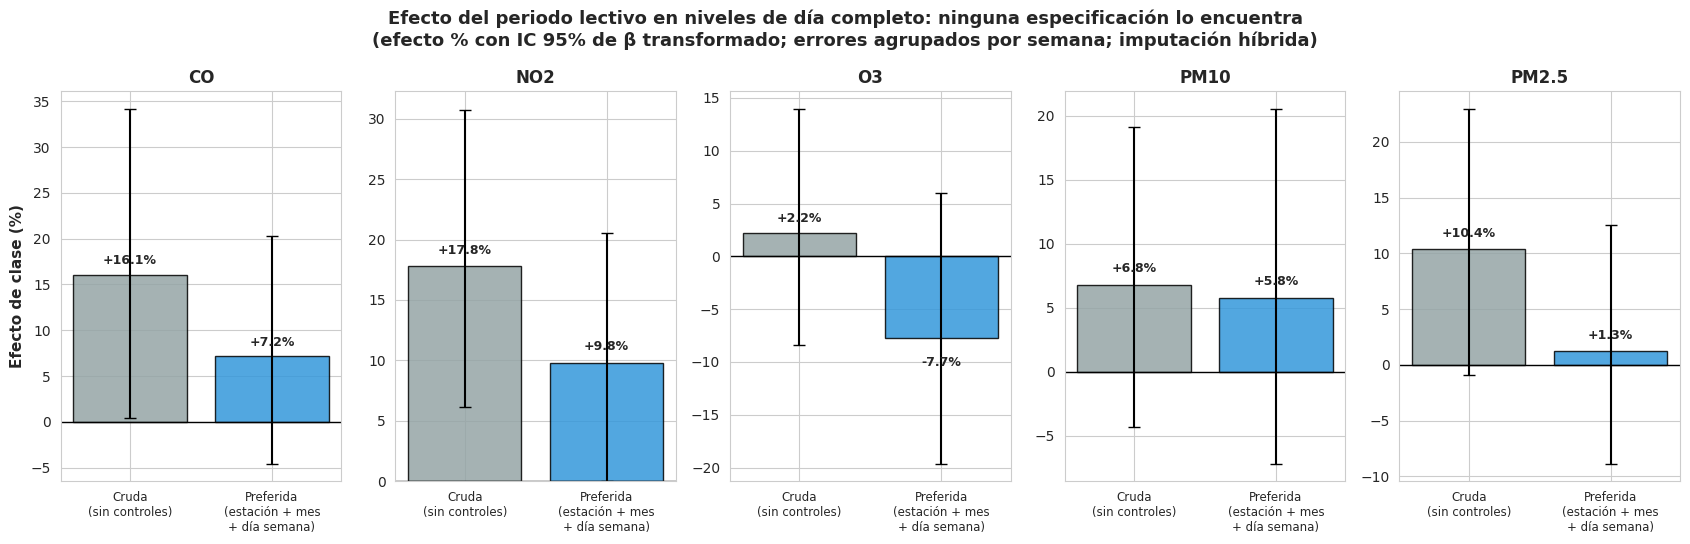

Guardado gráfico en: ../data_processed/graficos_metodos/02_sur_especificaciones.png


In [5]:
fig, axes = plt.subplots(1, 5, figsize=(17, 5.5))
especificaciones_grafica = ['cruda', 'preferida']
etiquetas_espec = ['Cruda\n(sin controles)', 'Preferida\n(estación + mes\n+ día semana)']

for i, c in enumerate(contaminantes):
    ax = axes[i]
    r_h = resultados['hibrido']
    valores = [r_h[e]['por_var'][f'l_{c}']['pct'] for e in especificaciones_grafica]
    err_lo = [valores[j] - r_h[e]['por_var'][f'l_{c}']['ci_lo_pct'] for j, e in enumerate(especificaciones_grafica)]
    err_hi = [r_h[e]['por_var'][f'l_{c}']['ci_hi_pct'] - valores[j] for j, e in enumerate(especificaciones_grafica)]
    colores_barras = ['#95a5a6', '#3498db']
    bars = ax.bar(range(len(especificaciones_grafica)), valores, yerr=[err_lo, err_hi], color=colores_barras,
                  alpha=0.85, edgecolor='black', capsize=4)
    for bar, valor in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (0.8 if valor >= 0 else -3.0),
                f'{valor:+.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(c, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(especificaciones_grafica)))
    ax.set_xticklabels(etiquetas_espec, fontsize=8.5)
    if i == 0:
        ax.set_ylabel('Efecto de clase (%)', fontsize=11, fontweight='bold')

fig.suptitle('Efecto del periodo lectivo en niveles de día completo: ninguna especificación lo encuentra\n(efecto % con IC 95% de β transformado; errores agrupados por semana; imputación híbrida)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(graficos_dir / '02_sur_especificaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado gráfico en: {graficos_dir / '02_sur_especificaciones.png'}")

## 6. Robustez: pruebas de falsación (clase falsa) y leave-one-station-out

La clase falsa alterna semanas ISO pares e impares dentro de un solo régimen (solo
vacaciones o solo clases), donde ninguna actividad escolar distingue a los grupos.
Hay que leerla con cuidado: semanas consecutivas no son intercambiables en todo
(autocorrelación, quincenas, feriados), así que un resultado nulo apoya el diseño
pero no lo demuestra.

In [6]:
panel['wknum'] = (panel['date'].dt.isocalendar().year.astype(int) * 100
                  + panel['date'].dt.isocalendar().week.astype(int))

robustez = {}
for nombre, sub in (('placebo_vacaciones', panel[panel['clase'] == 0]),
                    ('placebo_clases', panel[panel['clase'] == 1])):
    s = sub.copy()
    s['clase'] = (s['wknum'] % 2).astype(int)
    Xs = matriz_diseno(s, 'preferida')
    robustez[nombre] = sur_wald_cluster(s, Xs, columnas_log, 'wk')

robustez['loso'] = {}
for estacion_m in sorted(panel['estacion'].unique()):
    s = panel[panel['estacion'] != estacion_m]
    Xs = matriz_diseno(s, 'preferida')
    r = sur_wald_cluster(s, Xs, columnas_log, 'wk')
    robustez['loso'][f'sin_{estacion_m}'] = {
        'p_conjunto': r['p_chi2'],
        'CO_pct': r['por_var']['l_CO']['pct'],
        'NO2_pct': r['por_var']['l_NO2']['pct']}

print("=" * 70)
print("ROBUSTEZ")
print("=" * 70)
print(f"Clase falsa dentro de vacaciones (paridad de semana): p = {robustez['placebo_vacaciones']['p_chi2']}")
print(f"Clase falsa dentro de clases: p = {robustez['placebo_clases']['p_chi2']}")
print("\nLeave-one-station-out (p conjunto quitando cada estación):")
for nombre, r in robustez['loso'].items():
    print(f"  {nombre}: p = {r['p_conjunto']} (CO {r['CO_pct']:+.1f}%, NO2 {r['NO2_pct']:+.1f}%)")

with open(resultados_dir / 'sur_robustez.json', 'w') as f:
    json.dump(robustez, f, indent=2, ensure_ascii=False)
print(f"\nGuardado en: {resultados_dir / 'sur_robustez.json'}")

print('\nFINALIZADO')

ROBUSTEZ
Clase falsa dentro de vacaciones (paridad de semana): p = 0.5983
Clase falsa dentro de clases: p = 0.758018

Leave-one-station-out (p conjunto quitando cada estación):
  sin_CENTRO: p = 0.283671 (CO +7.5%, NO2 +9.8%)
  sin_NORESTE3: p = 0.314294 (CO +6.8%, NO2 +10.3%)
  sin_NOROESTE3: p = 0.197889 (CO +9.1%, NO2 +9.7%)
  sin_NORTE2: p = 0.357353 (CO +6.7%, NO2 +10.2%)
  sin_SUR: p = 0.356457 (CO +6.8%, NO2 +8.9%)
  sin_SUROESTE2: p = 0.384413 (CO +6.2%, NO2 +10.0%)

Guardado en: ../data_processed/resultados_metodos/sur_robustez.json

FINALIZADO
